Loaded processed panel: outputs_baseline/panel_df_with_unemp_s.csv
Shape: (8568, 35)

BASELINE PLACEBO SCM-TDA START | embedding=(3,1)
Treatment start: 2011-04-01
Derived trperiod: 424
Complete-case states: 46

Missouri H1 Wasserstein distance: 1.185979

Top Missouri donor weights:
KENTUCKY        4.739602e-01
NEBRASKA        2.205742e-01
CONNECTICUT     1.109565e-01
NEVADA          7.619407e-02
RHODE ISLAND    5.281156e-02
OHIO            4.947180e-02
NORTH DAKOTA    1.299611e-02
ARIZONA         3.035514e-03
HAWAII          5.841551e-17
MISSISSIPPI     4.256884e-17
dtype: float64
[01/45] ARIZONA              | distance=0.457244              | total= 12.39m | ETA=14:48:13
[02/45] ALABAMA              | distance=0.649901              | total= 13.36m | ETA=10:31:13
[03/45] DISTRICT OF COLUMBIA | FAILED (W optimization failed: Iteration limit reached) | total= 13.62m | ETA=08:55:00
[04/45] HAWAII               | distance=0.389086              | total= 14.63m | ETA=08:15:18
[05/45] ALASKA 

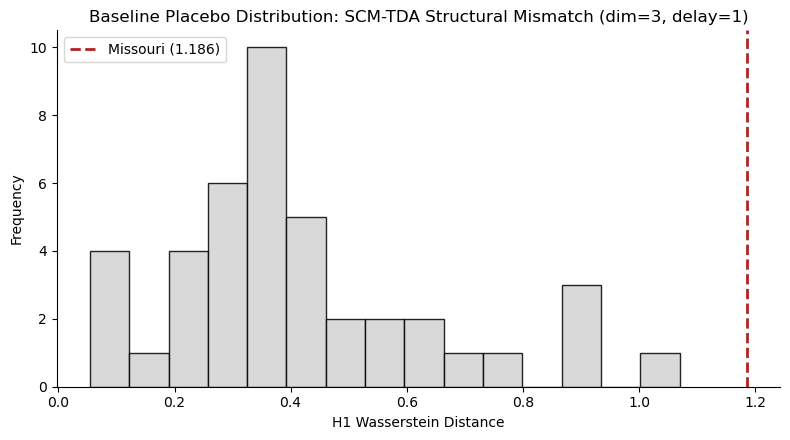


Top 10 placebo distances (highest mismatch):
NEBRASKA        1.069534
ALASKA          0.904513
SOUTH DAKOTA    0.876676
VERMONT         0.873158
MAINE           0.798186
KENTUCKY        0.689984
ALABAMA         0.649901
PENNSYLVANIA    0.621917
TEXAS           0.578834
KANSAS          0.571912
dtype: float64

Ranking of all states (including Missouri):
MISSOURI        1.185979
NEBRASKA        1.069534
ALASKA          0.904513
SOUTH DAKOTA    0.876676
VERMONT         0.873158
MAINE           0.798186
KENTUCKY        0.689984
ALABAMA         0.649901
PENNSYLVANIA    0.621917
TEXAS           0.578834
dtype: float64


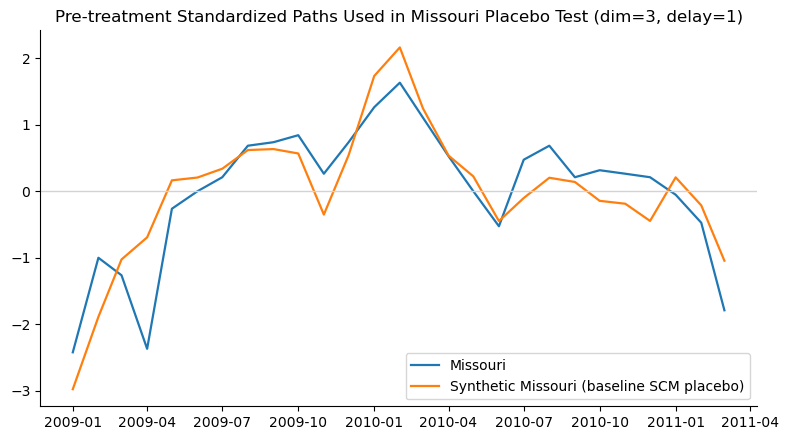


BASELINE PLACEBO SCM-TDA START | embedding=(2,1)
Treatment start: 2011-04-01
Derived trperiod: 424
Complete-case states: 46

Missouri H1 Wasserstein distance: 0.618130

Top Missouri donor weights:
KENTUCKY        4.739602e-01
NEBRASKA        2.205742e-01
CONNECTICUT     1.109565e-01
NEVADA          7.619407e-02
RHODE ISLAND    5.281156e-02
OHIO            4.947180e-02
NORTH DAKOTA    1.299611e-02
ARIZONA         3.035514e-03
HAWAII          5.841551e-17
MISSISSIPPI     4.256884e-17
dtype: float64
[01/45] ARIZONA              | distance=0.073306              | total= 13.32m | ETA=16:59:34
[02/45] ALABAMA              | distance=0.454683              | total= 14.72m | ETA=12:31:15
[03/45] CONNECTICUT          | distance=0.089919              | total= 14.90m | ETA=10:43:33
[04/45] ALASKA               | distance=0.248559              | total= 15.30m | ETA=09:52:15
[05/45] DISTRICT OF COLUMBIA | FAILED (W optimization failed: Iteration limit reached) | total= 16.48m | ETA=09:28:27
[06/45]

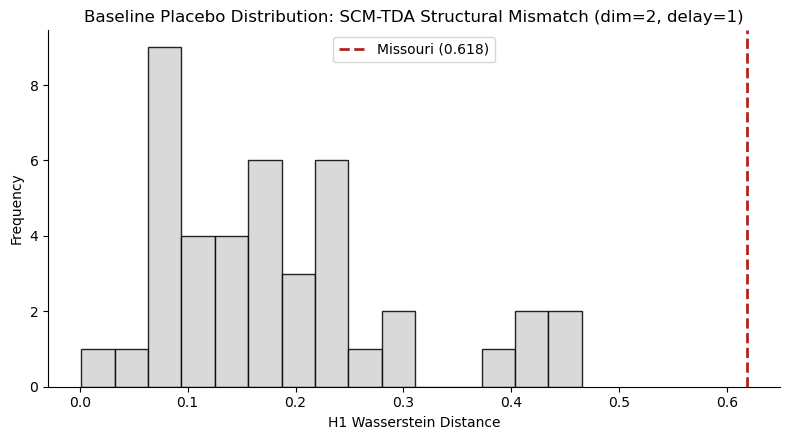


Top 10 placebo distances (highest mismatch):
NEBRASKA        0.465125
ALABAMA         0.454683
MAINE           0.417399
SOUTH DAKOTA    0.404177
HAWAII          0.399393
OHIO            0.287523
TENNESSEE       0.282832
KENTUCKY        0.261009
UTAH            0.248643
ALASKA          0.248559
dtype: float64

Ranking of all states (including Missouri):
MISSOURI        0.618130
NEBRASKA        0.465125
ALABAMA         0.454683
MAINE           0.417399
SOUTH DAKOTA    0.404177
HAWAII          0.399393
OHIO            0.287523
TENNESSEE       0.282832
KENTUCKY        0.261009
UTAH            0.248643
dtype: float64


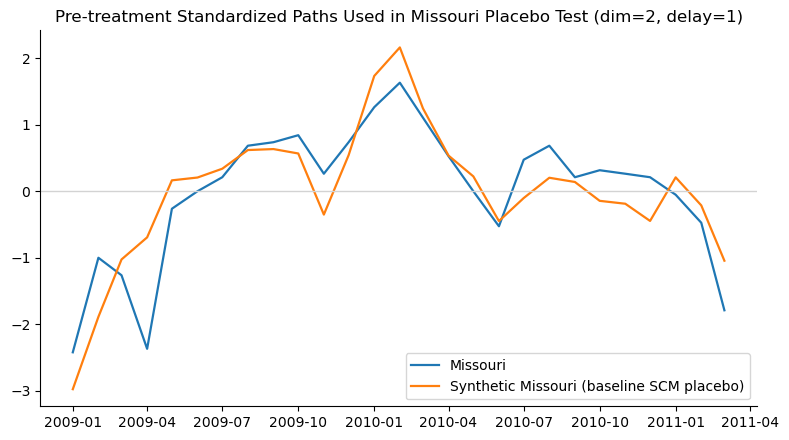


=== BASELINE PLACEBO ROBUSTNESS SUMMARY TABLE ===
embedding  dim  delay treatment_start  trperiod  missouri_h1_wasserstein  placebo_mean  placebo_median  ratio_to_placebo_mean  excess_over_placebo_mean  percentile_rank_right_tail  p_value_right_tail  valid_placebo_states  failed_states  significant_5pct evidence_strength
    (3,1)    3      1      2011-04-01       424                 1.185979      0.417335        0.376010               2.841791                  0.768644                       100.0            0.023256                    42              3              True            strong
    (2,1)    2      1      2011-04-01       424                 0.618130      0.185305        0.163415               3.335745                  0.432825                       100.0            0.023256                    42              3              True            strong

Saved outputs in: outputs_baseline_placebo
 - baseline_placebo_3_1_placebo_distances.csv
 - baseline_placebo_2_1_placebo_distance

In [1]:
# ============================================================
# 05_baseline_placebo
# Purpose:
#   - load processed panel from 03_baseline_scm
#   - run full placebo SCM-TDA under baseline SCM
#   - only for:
#       (3,1) main specification
#       (2,1) robustness specification
#   - save placebo distributions, summary tables, and pdf plots
# ============================================================

import os
import time
from datetime import datetime, timedelta
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from ripser import ripser
from persim import wasserstein

# ------------------------------------------------------------
# 0) Paths and settings
# ------------------------------------------------------------
INPUT_DIR = "outputs_baseline"
OUTPUT_DIR = "outputs_baseline_placebo"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PANEL_PATH = os.path.join(INPUT_DIR, "panel_df_with_unemp_s.csv")

TREATMENT_START = pd.Timestamp("2011-04-01")
DROP_STATES = {"FLORIDA", "ARKANSAS", "MICHIGAN", "SOUTH CAROLINA", "GEORGIA"}

# IMPORTANT:
# Since treatment starts in April 2011, do not include post-treatment anchors.
ANCHOR_STATIC = 409
ANCHOR_UNEMP = [397, 401, 405, 409, 413, 417, 421]

STATIC_COLS = ["pct_rural", "Chg1999_2006", "Chg2007_2010", "p12", "p_naics3", "p_naics4"]

EMBEDDING_SPECS = [
    (3, 1),   # main
    (2, 1),   # robustness
]

# ------------------------------------------------------------
# 1) Load processed panel
# ------------------------------------------------------------
panel_df = pd.read_csv(PANEL_PATH)
panel_df["date"] = pd.to_datetime(panel_df["date"])

required_cols = [
    "state", "date", "mo_yr", "unemp_s",
    "pct_rural", "Chg1999_2006", "Chg2007_2010",
    "p12", "p_naics3", "p_naics4"
]
missing_cols = [c for c in required_cols if c not in panel_df.columns]
if missing_cols:
    raise ValueError(f"panel_df 缺少这些列: {missing_cols}")

print("Loaded processed panel:", PANEL_PATH)
print("Shape:", panel_df.shape)

# ------------------------------------------------------------
# 2) SCM optimizer
# ------------------------------------------------------------
def solve_w_given_v_np(X1, X0, v):
    V = np.diag(v)

    def obj(w):
        d = X1 - X0 @ w
        return float(d.T @ V @ d)

    J = X0.shape[1]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J
    w0 = np.repeat(1.0 / J, J)

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 200, "ftol": 1e-7, "disp": False}
    )
    if not res.success:
        raise RuntimeError(f"W optimization failed: {res.message}")
    return res.x


def fit_synth_nested_np(X1, X0, Z1, Z0):
    K = X0.shape[0]

    def outer_obj(v_raw):
        v = np.maximum(v_raw, 1e-8)
        v = v / v.sum()
        w = solve_w_given_v_np(X1, X0, v)
        z_gap = Z1 - Z0 @ w
        return float(np.mean(z_gap ** 2))

    v0 = np.repeat(1.0 / K, K)
    cons = [{"type": "eq", "fun": lambda v: np.sum(v) - 1.0}]
    bounds = [(1e-8, 1.0)] * K

    res_v = minimize(
        outer_obj,
        v0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 120, "ftol": 1e-7, "disp": False}
    )
    if not res_v.success:
        raise RuntimeError(f"V optimization failed: {res_v.message}")

    v_star = np.maximum(res_v.x, 1e-8)
    v_star = v_star / v_star.sum()
    w_star = solve_w_given_v_np(X1, X0, v_star)
    return v_star, w_star

# ------------------------------------------------------------
# 3) TDA helpers
# ------------------------------------------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=0)
    if s == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / s

def delay_embed(x, dim=3, delay=1):
    x = np.asarray(x, dtype=float)
    n = len(x) - (dim - 1) * delay
    if n <= 0:
        raise ValueError(f"Series too short: len={len(x)}, dim={dim}, delay={delay}")
    return np.column_stack([x[i*delay : i*delay + n] for i in range(dim)])

def h1_wasserstein_from_series(seq1, seq2, dim=3, delay=1):
    s1 = zscore(seq1)
    s2 = zscore(seq2)

    cloud1 = delay_embed(s1, dim=dim, delay=delay)
    cloud2 = delay_embed(s2, dim=dim, delay=delay)

    dgm1 = ripser(cloud1, maxdim=1)["dgms"][1]
    dgm2 = ripser(cloud2, maxdim=1)["dgms"][1]

    if len(dgm1) > 0:
        dgm1 = dgm1[np.isfinite(dgm1[:, 1])]
    if len(dgm2) > 0:
        dgm2 = dgm2[np.isfinite(dgm2[:, 1])]

    if len(dgm1) == 0 and len(dgm2) == 0:
        return 0.0

    return float(wasserstein(dgm1, dgm2))

# ------------------------------------------------------------
# 4) Prepare common matrices
# ------------------------------------------------------------
def prepare_baseline_placebo_inputs(panel_df, treatment_start):
    synth_df = panel_df.loc[~panel_df["state"].isin(DROP_STATES)].copy()
    synth_df = synth_df[(synth_df["mo_yr"] >= 397) & (synth_df["mo_yr"] <= 452)].copy()

    tr_match = synth_df.loc[synth_df["date"] == treatment_start, "mo_yr"].drop_duplicates()
    if len(tr_match) != 1:
        raise ValueError(
            f"Expected exactly one mo_yr for treatment_start={treatment_start.date()}, got {tr_match.tolist()}"
        )
    trperiod = int(tr_match.iloc[0])

    static_block = (
        synth_df.loc[synth_df["mo_yr"] == ANCHOR_STATIC, ["state"] + STATIC_COLS]
        .drop_duplicates(subset=["state"])
        .set_index("state")
    )

    dyn_block = (
        synth_df.loc[synth_df["mo_yr"].isin(ANCHOR_UNEMP), ["state", "mo_yr", "unemp_s"]]
        .pivot(index="state", columns="mo_yr", values="unemp_s")
    )
    dyn_block.columns = [f"unemp_s_{c}" for c in dyn_block.columns]

    X_full = static_block.join(dyn_block, how="inner").sort_index()

    pre_panel = (
        synth_df.loc[synth_df["mo_yr"] < trperiod, ["state", "mo_yr", "unemp_s"]]
        .pivot(index="mo_yr", columns="state", values="unemp_s")
        .sort_index()
    )

    x_complete = X_full.dropna().index.tolist()
    z_complete = pre_panel.columns[~pre_panel.isna().any(axis=0)].tolist()

    common_states = sorted(set(x_complete).intersection(z_complete))

    X_full = X_full.loc[common_states]
    pre_panel = pre_panel[common_states]

    if "MISSOURI" not in common_states:
        raise ValueError("MISSOURI 不在完整样本里，无法继续。")

    state_to_idx = {s: i for i, s in enumerate(common_states)}
    missouri_idx = state_to_idx["MISSOURI"]

    X_mat = X_full.loc[common_states].to_numpy(dtype=float)
    Z_mat = pre_panel[common_states].to_numpy(dtype=float)

    return synth_df, trperiod, common_states, X_mat, Z_mat, missouri_idx

# ------------------------------------------------------------
# 5) Worker
# ------------------------------------------------------------
def compute_tda_for_index_worker(treated_idx, X_mat, Z_mat, common_states, dim=3, delay=1, return_weights=False):
    treated_state = common_states[treated_idx]

    donor_mask = np.ones(len(common_states), dtype=bool)
    donor_mask[treated_idx] = False

    donor_states = [common_states[i] for i in np.where(donor_mask)[0]]

    X1 = X_mat[treated_idx]
    X0 = X_mat[donor_mask].T

    Z1 = Z_mat[:, treated_idx]
    Z0 = Z_mat[:, donor_mask]

    _, w_star = fit_synth_nested_np(X1, X0, Z1, Z0)
    synthetic_pre = Z0 @ w_star

    dist = h1_wasserstein_from_series(Z1, synthetic_pre, dim=dim, delay=delay)

    if return_weights:
        return {
            "treated_state": treated_state,
            "distance": dist,
            "donor_states": donor_states,
            "weights": w_star,
            "treated_pre": Z1,
            "synthetic_pre": synthetic_pre
        }
    else:
        return treated_state, dist

# ------------------------------------------------------------
# 6) Run one placebo experiment
# ------------------------------------------------------------
def run_baseline_placebo_tda(
    panel_df,
    embed_dim=3,
    embed_delay=1,
    treatment_start=pd.Timestamp("2011-04-01"),
    max_workers=6,
    save_prefix="baseline_placebo"
):
    synth_df, trperiod, common_states, X_mat, Z_mat, missouri_idx = prepare_baseline_placebo_inputs(
        panel_df, treatment_start
    )

    print("\n" + "=" * 72)
    print(f"BASELINE PLACEBO SCM-TDA START | embedding=({embed_dim},{embed_delay})")
    print("Treatment start:", treatment_start.date())
    print("Derived trperiod:", trperiod)
    print("Complete-case states:", len(common_states))
    print("=" * 72)

    start_clock = time.time()
    start_stamp = datetime.now()

    mo_detail = compute_tda_for_index_worker(
        treated_idx=missouri_idx,
        X_mat=X_mat,
        Z_mat=Z_mat,
        common_states=common_states,
        dim=embed_dim,
        delay=embed_delay,
        return_weights=True
    )

    mo_dist = mo_detail["distance"]
    mo_weights_series = pd.Series(
        mo_detail["weights"],
        index=mo_detail["donor_states"]
    ).sort_values(ascending=False)

    print(f"\nMissouri H1 Wasserstein distance: {mo_dist:.6f}")
    print("\nTop Missouri donor weights:")
    print(mo_weights_series.head(10))

    placebo_indices = [i for i, s in enumerate(common_states) if s != "MISSOURI"]
    placebo_distances = {}
    failed_states = {}

    completed = 0
    n_total = len(placebo_indices)

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(
                compute_tda_for_index_worker,
                i, X_mat, Z_mat, common_states, embed_dim, embed_delay, False
            ): i
            for i in placebo_indices
        }

        for fut in as_completed(futures):
            completed += 1
            idx = futures[fut]
            st = common_states[idx]

            try:
                treated_state, dist = fut.result()
                if np.isfinite(dist):
                    placebo_distances[treated_state] = dist
                    status = f"distance={dist:.6f}"
                else:
                    failed_states[treated_state] = "Non-finite distance"
                    status = "FAILED (non-finite distance)"
            except Exception as e:
                failed_states[st] = str(e)
                status = f"FAILED ({e})"

            total_elapsed = time.time() - start_clock
            avg_per_state = total_elapsed / completed
            remaining = n_total - completed
            eta_seconds = remaining * avg_per_state
            eta_clock = datetime.now() + timedelta(seconds=eta_seconds)

            print(
                f"[{completed:02d}/{n_total:02d}] {st:<20} | {status:<30} "
                f"| total={total_elapsed/60:6.2f}m | ETA={eta_clock.strftime('%H:%M:%S')}"
            )

    end_clock = time.time()
    end_stamp = datetime.now()
    elapsed = end_clock - start_clock

    placebo_series = pd.Series(placebo_distances).sort_values()

    print("\n" + "=" * 72)
    print(f"BASELINE PLACEBO SCM-TDA END | embedding=({embed_dim},{embed_delay})")
    print("End time:", end_stamp.strftime("%Y-%m-%d %H:%M:%S"))
    print(f"Total elapsed: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    print(f"Valid placebo states: {len(placebo_series)}")
    print(f"Failed states: {len(failed_states)}")
    if len(failed_states) > 0:
        print("\nFirst 10 failures:")
        print(pd.Series(failed_states).head(10))
    print("=" * 72)

    if len(placebo_series) == 0:
        raise ValueError("没有有效 placebo 距离，无法做推断。")

    p_right = (1 + np.sum(placebo_series.values >= mo_dist)) / (1 + len(placebo_series))
    pct_rank = np.mean(placebo_series.values < mo_dist)

    print("\n=== BASELINE PLACEBO INFERENCE ===")
    print(f"Missouri H1 Wasserstein distance: {mo_dist:.6f}")
    print(f"Placebo mean distance          : {placebo_series.mean():.6f}")
    print(f"Placebo median distance        : {placebo_series.median():.6f}")
    print(f"Percentile rank (right tail)  : {pct_rank*100:.1f}%")
    print(f"Conservative right-tail p-val : {p_right:.6f}")

    emb_tag = f"{embed_dim}_{embed_delay}"

    # save distances and failures
    placebo_series.to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_placebo_distances.csv"))
    pd.Series(failed_states).to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_failed_states.csv"))
    mo_weights_series.to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_missouri_weights.csv"))

    # histogram
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(placebo_series.values, bins=15, color="lightgray", edgecolor="black", alpha=0.85)
    ax.axvline(mo_dist, color="firebrick", linewidth=2, linestyle="--",
               label=f"Missouri ({mo_dist:.3f})")

    ax.set_xlabel("H1 Wasserstein Distance")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Baseline Placebo Distribution: SCM-TDA Structural Mismatch (dim={embed_dim}, delay={embed_delay})")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_histogram.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # ranking
    all_dists = pd.concat([pd.Series({"MISSOURI": mo_dist}), placebo_series]).sort_values(ascending=False)
    all_dists.to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_all_rankings.csv"))

    print("\nTop 10 placebo distances (highest mismatch):")
    print(placebo_series.sort_values(ascending=False).head(10))

    print("\nRanking of all states (including Missouri):")
    print(all_dists.head(10))

    # pre-treatment standardized paths used in Missouri placebo construction
    pre_dates = (
        synth_df.loc[
            (synth_df["state"] == "MISSOURI") & (synth_df["mo_yr"] < trperiod),
            ["mo_yr", "date"]
        ]
        .drop_duplicates()
        .sort_values("mo_yr")
    )

    missouri_placebo_df = pre_dates.copy()
    missouri_placebo_df["treated_pre"] = mo_detail["treated_pre"]
    missouri_placebo_df["synthetic_pre"] = mo_detail["synthetic_pre"]
    missouri_placebo_df["treated_pre_z"] = zscore(missouri_placebo_df["treated_pre"])
    missouri_placebo_df["synthetic_pre_z"] = zscore(missouri_placebo_df["synthetic_pre"])

    missouri_placebo_df.to_csv(
        os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_missouri_pre_paths.csv"),
        index=False
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(missouri_placebo_df["date"], missouri_placebo_df["treated_pre_z"],
            label="Missouri", linewidth=1.6)
    ax.plot(missouri_placebo_df["date"], missouri_placebo_df["synthetic_pre_z"],
            label="Synthetic Missouri (baseline SCM placebo)", linewidth=1.6)
    ax.axhline(0, color="lightgray", linewidth=1)
    ax.set_title(f"Pre-treatment Standardized Paths Used in Missouri Placebo Test (dim={embed_dim}, delay={embed_delay})")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{save_prefix}_{emb_tag}_missouri_pre_paths.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    result = {
        "embedding": f"({embed_dim},{embed_delay})",
        "dim": embed_dim,
        "delay": embed_delay,
        "treatment_start": treatment_start,
        "trperiod": trperiod,
        "missouri_h1_wasserstein": mo_dist,
        "placebo_mean": float(placebo_series.mean()),
        "placebo_median": float(placebo_series.median()),
        "ratio_to_placebo_mean": float(mo_dist / placebo_series.mean()) if placebo_series.mean() != 0 else np.nan,
        "excess_over_placebo_mean": float(mo_dist - placebo_series.mean()),
        "percentile_rank_right_tail": float(pct_rank * 100),
        "p_value_right_tail": float(p_right),
        "valid_placebo_states": int(len(placebo_series)),
        "failed_states": int(len(failed_states)),
        "significant_5pct": bool(p_right < 0.05),
        "evidence_strength": (
            "strong" if p_right < 0.05 else
            "moderate" if p_right < 0.10 else
            "weak"
        )
    }

    return result

# ------------------------------------------------------------
# 7) Run all requested embeddings
# ------------------------------------------------------------
all_results = []

for embed_dim, embed_delay in EMBEDDING_SPECS:
    res = run_baseline_placebo_tda(
        panel_df=panel_df,
        embed_dim=embed_dim,
        embed_delay=embed_delay,
        treatment_start=TREATMENT_START,
        max_workers=6,
        save_prefix="baseline_placebo"
    )
    all_results.append(res)

# ------------------------------------------------------------
# 8) Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame(all_results)

print("\n=== BASELINE PLACEBO ROBUSTNESS SUMMARY TABLE ===")
print(summary_df.round(6).to_string(index=False))

summary_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_placebo_summary.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "baseline_placebo_summary.txt"), "w", encoding="utf-8") as f:
    f.write("=== BASELINE PLACEBO ROBUSTNESS SUMMARY TABLE ===\n")
    f.write(summary_df.round(6).to_string(index=False))

print(f"\nSaved outputs in: {OUTPUT_DIR}")
print(" - baseline_placebo_3_1_placebo_distances.csv")
print(" - baseline_placebo_2_1_placebo_distances.csv")
print(" - baseline_placebo_3_1_histogram.pdf")
print(" - baseline_placebo_2_1_histogram.pdf")
print(" - baseline_placebo_3_1_missouri_weights.csv")
print(" - baseline_placebo_2_1_missouri_weights.csv")
print(" - baseline_placebo_3_1_missouri_pre_paths.pdf")
print(" - baseline_placebo_2_1_missouri_pre_paths.pdf")
print(" - baseline_placebo_summary.csv")
print(" - baseline_placebo_summary.txt")